In [1]:
library(auk)
library(tidyverse)

library(magrittr)
library(httr)
library(data.table)
library(plotly)
# library(elevatr)
library(readr)
library(raster)

library(sf)
library(terra)
# library(prism)
# library(rnaturalearth)
library(dggridR)
library(lubridate)
library(hms)

library(gridExtra)

select <- dplyr::select
projection <- raster::projection

readRenviron("~/.Renviron")
R.home()

auk 0.9.0 is designed for EBD files downloaded after 2025-10-28. 
No EBD data directory set, see ?auk_set_ebd_path to set EBD_PATH 
eBird taxonomy version:  2025

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, isoyear, mday, minute, month

[1] "/usr/lib/R"

In [2]:
PROJECT_DIR = getwd()

ebd_dir = file.path(PROJECT_DIR, "source_data", "ebd_relMar-2026")
ebd_filename = "ebd_relMar-2026.txt"

sed_dir = file.path(PROJECT_DIR, "source_data", "ebd_sampling_relMar-2026")
sed_filename = "ebd_sampling_relMar-2026.txt"

In [3]:
auk_version()
auk_ebd_version(file.path(ebd_dir, ebd_filename))

$auk_version
[1] "auk 0.9.0"

$ebd_version
[1] "2025-10-28"

$taxonomy_version
[1] 2025

ERROR: Error in ebd_file(x): File not found:
 /media/user474/Storage_Root_INT/Education/Illinois/06-CS_416-Data_Visualization/Narrative_Vis_Project/source_data/ebd_relMar-2026/ebd_relMar-2026.txt


In [ ]:
# source("ebd_functions.R")
# source("land_cover_functions.R")
# source("climate_functions.R")
# dist_to_coast_df = read_in_dist_to_coast_data(file.path(PROJECT_DIR, "source_data", "NASA_dist2coast.txt"))

<span style="color:deepskyblue">Citation:  
*eBird Basic Dataset. Version: EBD_relSep-2025. Cornell Lab of Ornithology, Ithaca, New York. Sep 2025.*</span>

### Data extraction

In [ ]:
# print all columns
readLines(file.path(ebd_dir, ebd_filename), n = 1) |> strsplit("\t") |> unlist()

[1] "GLOBAL UNIQUE IDENTIFIER"   "LAST EDITED DATE"          
 [3] "TAXONOMIC ORDER"            "CATEGORY"                  
 [5] "TAXON CONCEPT ID"           "COMMON NAME"               
 [7] "SCIENTIFIC NAME"            "SUBSPECIES COMMON NAME"    
 [9] "SUBSPECIES SCIENTIFIC NAME" "EXOTIC CODE"               
[11] "OBSERVATION COUNT"          "BREEDING CODE"             
[13] "BREEDING CATEGORY"          "BEHAVIOR CODE"             
[15] "AGE/SEX"                    "COUNTRY"                   
[17] "COUNTRY CODE"               "STATE"                     
[19] "STATE CODE"                 "COUNTY"                    
[21] "COUNTY CODE"                "IBA CODE"                  
[23] "BCR CODE"                   "USFWS CODE"                
[25] "ATLAS BLOCK"                "LOCALITY"                  
[27] "LOCALITY ID"                "LOCALITY TYPE"             
[29] "LATITUDE"                   "LONGITUDE"                 
[31] "OBSERVATION DATE"           "TIME OBSERVATIONS STARTED" 
[33] "OBSERVER ID"                "OBSERVER ORCID ID"         
[35] "SAMPLING EVENT IDENTIFIER"  "OBSERVATION TYPE"          
[37] "PROTOCOL NAME"              "PROTOCOL CODE"             
[39] "PROJECT NAMES"              "PROJECT IDENTIFIERS"       
[41] "DURATION MINUTES"           "EFFORT DISTANCE KM"        
[43] "EFFORT AREA HA"             "NUMBER OBSERVERS"          
[45] "ALL SPECIES REPORTED"       "GROUP IDENTIFIER"          
[47] "HAS MEDIA"                  "APPROVED"                  
[49] "REVIEWED"                   "REASON"                    
[51] "CHECKLIST COMMENTS"         "SPECIES COMMENTS"

#### <span style="color:orange">Swallow-tailed Kite, Fall migration</span>

In [ ]:
file.desc <- "swallow_tailed_kite_compl_20260726"
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

species_name = "Swallow-tailed Kite"
# Full dataset filtering
f_in_ebd <- file.path(ebd_dir, ebd_filename)
f_in_sed <- file.path(sed_dir, sed_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species(species_name) %>%
    auk_bbox(bbox = c(longitude_min = -108, latitude_min = -15, longitude_max = -50, latitude_max = 40)) %>%
    auk_date(c("*-08-01", "*-10-31")) %>%
    auk_complete()
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only,
           keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                    "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                    "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                    "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                    "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
           overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Swallow-tailed Kite"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”
Warning message in auk_filter.auk_ebd(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only, :
“Sampling event data file provided, but filters have not been  set to only return complete checklists. Complete checklists  are required for zero-filling. You may want to use  auk_complete(), or manually filter out incomplete checklists.”


In [151]:
# file.desc <- "swallow_tailed_kite_20260725"
# f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
# f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

# ebd_filters2 <- auk_ebd(f_out_ebd_only, file_sampling = f_out_sed_only) %>%
#     auk_complete()

# f_out_ebd_complete <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, "_complete.txt"))
# f_out_sed_complete <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, "_complete.txt"))

# auk_filter(ebd_filters2, file = f_out_ebd_complete, file_sampling = f_out_sed_complete,
#            overwrite = TRUE)

ERROR: Error in auk_ebd(f_out_ebd_only, file_sampling = f_out_sed_only): Required columns missing from the EBD file:
	exotic code


#### <span style="color:orange">Broad-winged Hawk, Fall migration</span>

In [ ]:
file.desc <- "broad_winged_hawk_compl_20260726"
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

species_name = "Broad-winged Hawk"
# Full dataset filtering
f_in_ebd <- file.path(ebd_dir, ebd_filename)
f_in_sed <- file.path(sed_dir, sed_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species(species_name) %>%
    auk_bbox(bbox = c(longitude_min = -108, latitude_min = -15, longitude_max = -50, latitude_max = 40)) %>%
    auk_date(c("*-08-01", "*-10-31")) %>%
    auk_complete()
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only,
           keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                    "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                    "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                    "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                    "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
           overwrite = TRUE)

#### <span style="color:orange">Mississippi Kite, Fall migration</span>

In [ ]:
file.desc <- "mississippi_kite_compl_20260727"
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

species_name = "Mississippi Kite"
# Full dataset filtering
f_in_ebd <- file.path(ebd_dir, ebd_filename)
f_in_sed <- file.path(sed_dir, sed_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species(species_name) %>%
    auk_bbox(bbox = c(longitude_min = -108, latitude_min = -15, longitude_max = -50, latitude_max = 40)) %>%
    auk_date(c("*-08-01", "*-10-31")) %>%
    auk_complete()
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only,
           keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                    "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                    "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                    "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                    "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
           overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Mississippi Kite"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”
Warning message in auk_filter.auk_ebd(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only, :
“Sampling event data file provided, but filters have not been  set to only return complete checklists. Complete checklists  are required for zero-filling. You may want to use  auk_complete(), or manually filter out incomplete checklists.”


Input 
  EBD: /media/user797/exHDD-02/ebd_relMar-2026/ebd_relMar-2026.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relMar-2026/ebd_sampling_relMar-2026.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/CS_416_Final_Project/output/auk/ebd_mississippi_kite_20260726.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/CS_416_Final_Project/output/auk/sed_mississippi_kite_20260726.txt 

Filters 
  Species: Ictinia mississippiensis
  Countries: all
  States: all
  Counties: all
  BCRs: all
  Bounding box: Lon -108 - -50; Lat -15 - 40
  Years: all
  Date: *-08-01 - *-10-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: no

#### Read data back in

In [4]:
file.desc <- "swallow_tailed_kite_compl_20260726"
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

ebd_only_df = read_ebd(f_out_ebd_only, unique=TRUE, rollup=TRUE) # do not need to use auk_unique() when unique=TRUE passed here. Same for auk_rollup()
sed_only_df = read_sampling(f_out_sed_only, unique=TRUE)

In [5]:
str(ebd_only_df)

tibble [28,432 × 21] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:28432] "G1000625" "G1001498" "G10016264" "G1002529" ...
 $ scientific_name          : chr [1:28432] "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" ...
 $ observation_count        : chr [1:28432] "2" "1" "1" "2" ...
 $ country                  : chr [1:28432] "United States" "Ecuador" "Costa Rica" "Ecuador" ...
 $ country_code             : chr [1:28432] "US" "EC" "CR" "EC" ...
 $ state                    : chr [1:28432] "Florida" "Orellana" "Puntarenas" "Napo" ...
 $ state_code               : chr [1:28432] "US-FL" "EC-D" "CR-P" "EC-N" ...
 $ latitude                 : num [1:28432] 24.742 -0.444 9.231 -0.676 24.742 ...
 $ longitude                : num [1:28432] -81 -76.7 -83.4 -77.6 -81 ...
 $ observation_date         : Date[1:28432], format: "2014-09-15" "2014-09-09" ...
 $ time_observations_started: chr [1:28432] "09:00:00" "12:00:00" "06:07:00" "12:36:

In [6]:
str(sed_only_df)

tibble [5,833,289 × 17] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:5833289] "S7223310" "S60476468" "S60413427" "S221217005" ...
 $ country                  : chr [1:5833289] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:5833289] "US" "US" "US" "US" ...
 $ state                    : chr [1:5833289] "Texas" "Indiana" "Louisiana" "New Mexico" ...
 $ state_code               : chr [1:5833289] "US-TX" "US-IN" "US-LA" "US-NM" ...
 $ latitude                 : num [1:5833289] 26.3 38.9 29.8 35.6 29.8 ...
 $ longitude                : num [1:5833289] -97.4 -86.4 -93.5 -105.9 -93.3 ...
 $ observation_date         : Date[1:5833289], format: "1992-08-04" "1989-08-09" ...
 $ time_observations_started: chr [1:5833289] "07:00:00" NA "08:00:00" NA ...
 $ observer_id              : chr [1:5833289] "obsr229232" "obsr614875" "obsr128996" "obsr349129" ...
 $ sampling_event_identifier: chr [1:5833289] "S7223310" "S60476468" "

### Clean and Filter

#### Zero-fill

In [7]:
ebd_zf_df <- auk_zerofill(ebd_only_df, sampling_events = sed_only_df,
                          collapse = TRUE)

#### Clean

In [8]:
str(ebd_zf_df)

tibble [5,833,289 × 20] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:5833289] "S7223310" "S60476468" "S60413427" "S221217005" ...
 $ country                  : chr [1:5833289] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:5833289] "US" "US" "US" "US" ...
 $ state                    : chr [1:5833289] "Texas" "Indiana" "Louisiana" "New Mexico" ...
 $ state_code               : chr [1:5833289] "US-TX" "US-IN" "US-LA" "US-NM" ...
 $ latitude                 : num [1:5833289] 26.3 38.9 29.8 35.6 29.8 ...
 $ longitude                : num [1:5833289] -97.4 -86.4 -93.5 -105.9 -93.3 ...
 $ observation_date         : Date[1:5833289], format: "1992-08-04" "1989-08-09" ...
 $ time_observations_started: chr [1:5833289] "07:00:00" NA "08:00:00" NA ...
 $ observer_id              : chr [1:5833289] "obsr229232" "obsr614875" "obsr128996" "obsr349129" ...
 $ sampling_event_identifier: chr [1:5833289] "S7223310" "S60476468" "

In [9]:
# function to convert time observation to hours since midnight
time_to_decimal <- function(x) {
  x <- as_hms(x)
  hour(x) + minute(x) / 60 + second(x) / 3600
}

ebd_df <- ebd_zf_df |> 
  mutate(
    # convert count to integer and X to NA
    observation_count = if_else(observation_count == "X", 
                                NA_character_, observation_count),
    observation_count = as.integer(observation_count),
    # ignore the warning "NAs introduced by coercion"
    effort_distance_km = if_else(protocol_name == "Stationary", 
                                  0, effort_distance_km),
    # convert time to decimal hours since midnight
    hours_of_day = time_to_decimal(time_observations_started),
    # split date into year and day of year
    year = year(observation_date),
    day_of_year = yday(observation_date)
  )

table(ebd_zf_df$species_observed)
# Removed effort-variability filter. Want to see all observations.
# https://strimas.com/ebp-workshop/presabs.html


  FALSE    TRUE 
5804857   28432 

In [10]:
str(ebd_df)

tibble [5,833,289 × 23] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:5833289] "S7223310" "S60476468" "S60413427" "S221217005" ...
 $ country                  : chr [1:5833289] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:5833289] "US" "US" "US" "US" ...
 $ state                    : chr [1:5833289] "Texas" "Indiana" "Louisiana" "New Mexico" ...
 $ state_code               : chr [1:5833289] "US-TX" "US-IN" "US-LA" "US-NM" ...
 $ latitude                 : num [1:5833289] 26.3 38.9 29.8 35.6 29.8 ...
 $ longitude                : num [1:5833289] -97.4 -86.4 -93.5 -105.9 -93.3 ...
 $ observation_date         : Date[1:5833289], format: "1992-08-04" "1989-08-09" ...
 $ time_observations_started: chr [1:5833289] "07:00:00" NA "08:00:00" NA ...
 $ observer_id              : chr [1:5833289] "obsr229232" "obsr614875" "obsr128996" "obsr349129" ...
 $ sampling_event_identifier: chr [1:5833289] "S7223310" "S60476468" "

In [190]:
file.desc <- "swallow_tailed_kite_compl_20260726"
ebd_df = read_csv(file.path(PROJECT_DIR, "output", paste0(file.desc, "_zf_clean.csv")))
head(ebd_df)
# str(ebd_df)

Rows: 5833289 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (10): checklist_id, country, country_code, state, state_code, observer_...
dbl   (9): latitude, longitude, duration_minutes, effort_distance_km, number...
lgl   (2): all_species_reported, species_observed
date  (1): observation_date
time  (1): time_observations_started

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


checklist_id,country,country_code,state,state_code,latitude,longitude,observation_date,time_observations_started,observer_id,⋯,effort_distance_km,number_observers,all_species_reported,group_identifier,scientific_name,observation_count,species_observed,hours_of_day,year,day_of_year
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<date>,<time>,<chr>,⋯,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
S7223310,United States,US,Texas,US-TX,26.25586,-97.37114,1992-08-04,07:00:00,obsr229232,⋯,NA,1,TRUE,NA,Elanoides forficatus,0,FALSE,7.00,1992,217
S60476468,United States,US,Indiana,US-IN,38.87544,-86.40829,1989-08-09,NA,obsr614875,⋯,NA,2,TRUE,NA,Elanoides forficatus,0,FALSE,NA,1989,221
S60413427,United States,US,Louisiana,US-LA,29.79451,-93.47096,1987-10-09,08:00:00,obsr128996,⋯,8.047,1,TRUE,NA,Elanoides forficatus,0,FALSE,8.00,1987,282
S221217005,United States,US,New Mexico,US-NM,35.62321,-105.92191,1974-08-15,NA,obsr349129,⋯,NA,1,TRUE,NA,Elanoides forficatus,0,FALSE,NA,1974,227
S34282021,United States,US,Louisiana,US-LA,29.80386,-93.34723,1987-10-04,07:45:00,obsr116124,⋯,0.402,2,TRUE,NA,Elanoides forficatus,0,FALSE,7.75,1987,277
S60536485,United States,US,Pennsylvania,US-PA,39.82850,-77.33595,1994-10-02,09:30:00,obsr292785,⋯,0.000,1,TRUE,NA,Elanoides forficatus,0,FALSE,9.50,1994,275


#### Write out

In [189]:
file.desc <- "swallow_tailed_kite_compl_20260726"
write_csv(ebd_df, file.path(PROJECT_DIR, "output", paste0(file.desc, "_zf_clean.csv")))

#### <span style="color:grey">Not filtering for effort</span>

### Aggregate into hex bins

In [11]:
# construct grid
dggs <- dgconstruct(spacing = 50, topology = "HEXAGON")

# get hexagonal cell id and week number for each checklist
ebd_with_cells <- ebd_df |>
  mutate(cell = dgGEO_to_SEQNUM(dggs, longitude, latitude)$seqnum,
         year = year(observation_date),
         week = week(observation_date))
# https://strimas.com/ebp-workshop/subsampling.html
str(ebd_with_cells)

Resolution: 9, Area (km^2): 2591.40182758771, Spacing (km): 50.276890494384, CLS (km): 57.4411078487275


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `week = week(observation_date)`.
Caused by warning in `convertDate()`:
! The default behavior of week() is changing. Previously ('legacy' mode), week numbers advanced every 7th day of the year. The new 'sequential' mode ensures the first week always has 7 days. For example, as.IDate('2023-01-07') returns week 2 in legacy mode but week 1 in sequential mode (week 2 starts on '2023-01-08'). To adopt the new behavior now, set options(datatable.week = 'sequential'). To keep the old results and silence this warning, set options(datatable.week = 'legacy'). See https://github.com/Rdatatable/data.table/issues/2611”


tibble [5,833,289 × 25] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:5833289] "S7223310" "S60476468" "S60413427" "S221217005" ...
 $ country                  : chr [1:5833289] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:5833289] "US" "US" "US" "US" ...
 $ state                    : chr [1:5833289] "Texas" "Indiana" "Louisiana" "New Mexico" ...
 $ state_code               : chr [1:5833289] "US-TX" "US-IN" "US-LA" "US-NM" ...
 $ latitude                 : num [1:5833289] 26.3 38.9 29.8 35.6 29.8 ...
 $ longitude                : num [1:5833289] -97.4 -86.4 -93.5 -105.9 -93.3 ...
 $ observation_date         : Date[1:5833289], format: "1992-08-04" "1989-08-09" ...
 $ time_observations_started: chr [1:5833289] "07:00:00" NA "08:00:00" NA ...
 $ observer_id              : chr [1:5833289] "obsr229232" "obsr614875" "obsr128996" "obsr349129" ...
 $ sampling_event_identifier: chr [1:5833289] "S7223310" "S60476468" "

In [12]:
# generate polygons for the grid cells
# hexagons <- dgcellstogrid(dggs, unique(pts$cell), frame = FALSE) %>% 
hexagons <- dgcellstogrid(dggs, unique(ebd_with_cells$cell)) %>% 
  st_as_sf()

In [13]:
hexagons$cell <- as.integer(hexagons$seqnum)
# convert to terra SpatVector
hexagons <- hexagons %>% select(cell, geometry)
hex_spatvector <- terra::vect(hexagons)

In [14]:
hex_spatvector

 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 5169, 1  (geometries, attributes)
 extent      : -108.5224, -49.55582, -15.47016, 40.53142  (xmin, xmax, ymin, ymax)
 coord. ref. : lon/lat WGS 84 (EPSG:4326) 
 names       :  cell
 type        : <int>
 values      : 14221
               14303
               14384

In [15]:
ebd_agg <- ebd_with_cells %>% 
  group_by(cell) %>% 
  # summarize(obs_freq = mean(observation_count)) %>% 
  summarize(n_checklists = n(),
            n_detected = sum(species_observed),
            det_freq = mean(species_observed)) %>% 
  ungroup() %>%
  mutate(cell_ctr_lat = dgSEQNUM_to_GEO(dggs, cell)$lat_deg,
         cell_ctr_lon = dgSEQNUM_to_GEO(dggs, cell)$lon_deg)
# https://www.rdocumentation.org/packages/dggridR/versions/3.1.0/topics/dgSEQNUM_to_GEO

In [16]:
str(ebd_agg)

tibble [5,169 × 6] (S3: tbl_df/tbl/data.frame)
 $ cell        : num [1:5169] 14221 14303 14384 14385 14464 ...
 $ n_checklists: int [1:5169] 7 216 1196 114 202 2608 499 688 3593 5114 ...
 $ n_detected  : int [1:5169] 0 0 0 0 0 0 0 0 0 0 ...
 $ det_freq    : num [1:5169] 0 0 0 0 0 0 0 0 0 0 ...
 $ cell_ctr_lat: num [1:5169] 40.1 40.1 39.6 40.1 39.2 ...
 $ cell_ctr_lon: num [1:5169] -108 -107 -108 -107 -108 ...


#### Plot

In [ ]:
# Reset plotting defaults in case the 1x2 layout cell was run earlier
if (exists("old_par")) {
    par(old_par)
} else {
    par(mfrow = c(1, 1), mar = c(5.1, 4.1, 4.1, 2.1))
}

# Remove custom Jupyter plot size overrides
options(repr.plot.width = NULL, repr.plot.height = NULL)

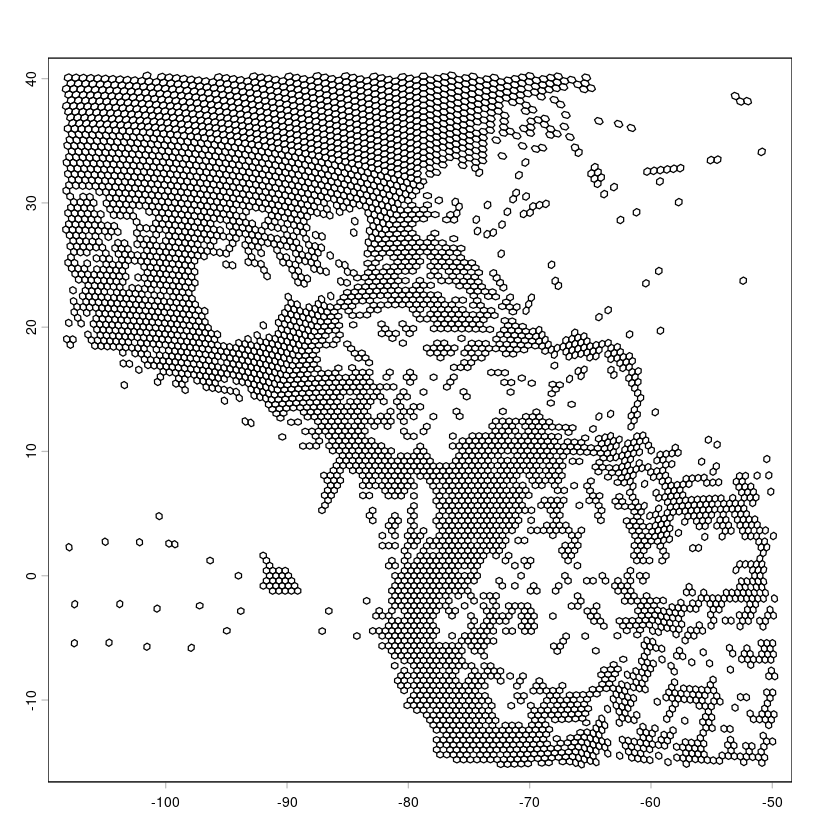

In [207]:
plot(hex_spatvector)
# all checklists in bbox

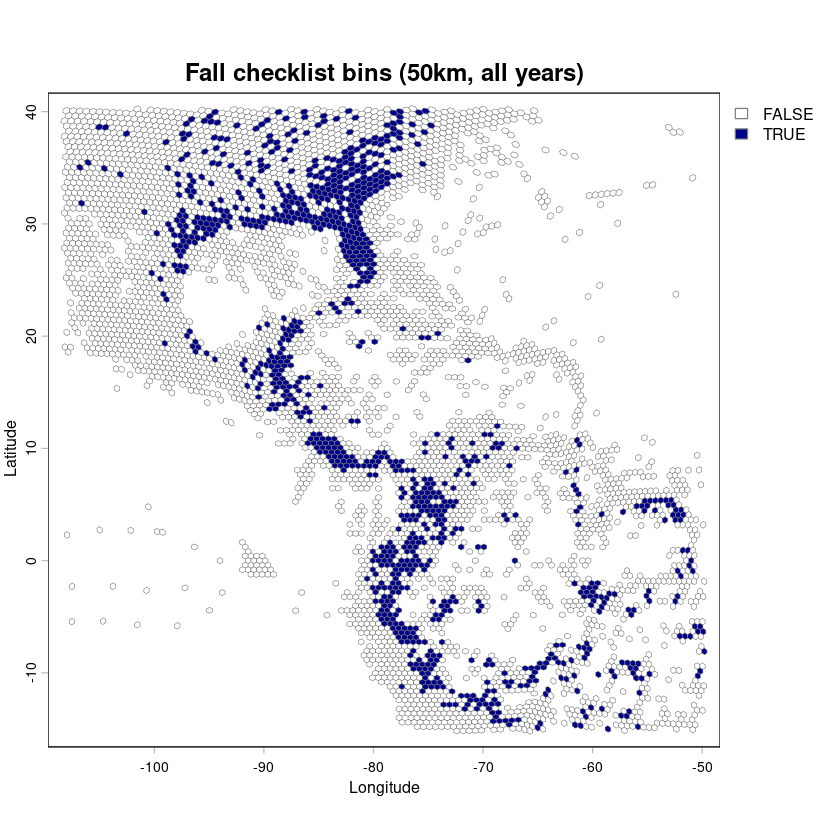

In [49]:
# Join aggregated data with hexagon spatial vector
hex_with_data <- hexagons %>%
    left_join(ebd_agg, by = "cell") %>%
    mutate(has_observation = (n_detected > 1))

# Convert to terra SpatVector
hex_spatvector_colored <- terra::vect(hex_with_data)
plot(
    hex_spatvector_colored, "has_observation",
    col = c("white", "darkblue"),
    border = "gray50",
    lwd = 0.5,
    main = "Fall checklist bins (50km, all years)",
    xlab = "Longitude", ylab = "Latitude",
    )

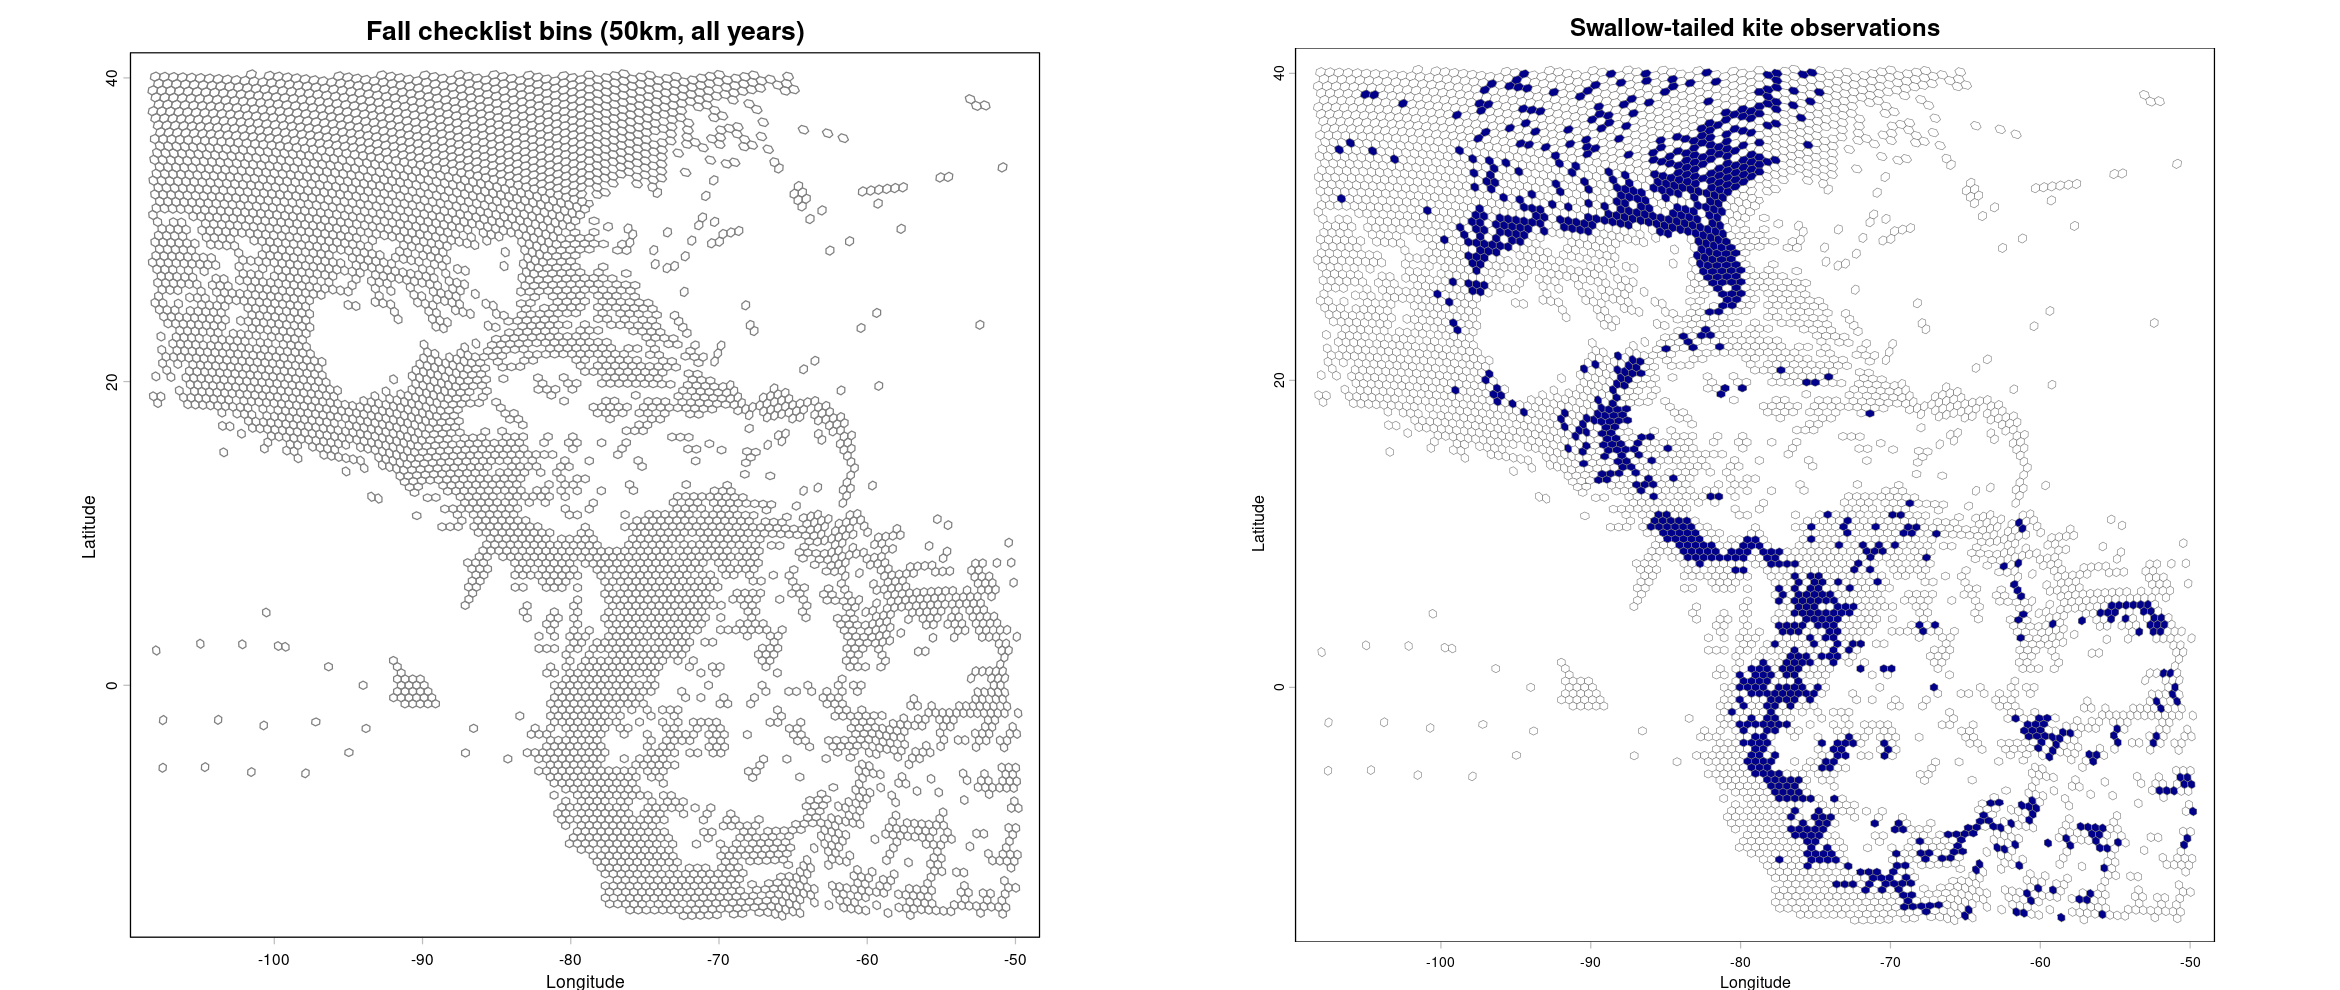

In [61]:
# Plot with custom edge color and thinner lines
# 1x2 layout; enlarge output area (~30%) for side-by-side panels in Jupyter
options(repr.plot.width = 13*1.5, repr.plot.height = 5.5*1.5)

old_par <- par(no.readonly = TRUE)
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1), cex = 1.1)

plot(
    hex_spatvector,
    border = "gray50",
    lwd = 1.0,
    main = "Fall checklist bins (50km, all years)",
    xlab = "Longitude", ylab = "Latitude"
)

par(mar = c(4, 4, 3, 4), cex = 1.0)

plot(
    hex_spatvector_colored, "has_observation",
    col = c("white", "darkblue"),
    border = "gray50",
    lwd = 0.5,
    main = "Swallow-tailed kite observations",
    xlab = "Longitude", ylab = "Latitude",
    legend = FALSE,
    yaxt = "n"
)

#### Write out

In [55]:
file.desc <- "swallow_tailed_kite_compl_20260726"
write_csv(ebd_agg, file.path(PROJECT_DIR, "output", paste0(file.desc, "_zf_clean_agg.csv")))